# Let's get going and preprocess some data 😏
 إنسان الي كاتب والله 😂

In [1]:
import tensorflow as tf
import keras
print("TF:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0
Keras: 3.12.0
GPU available: []


## Starter Code (Provided by the supervisor)

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from keras import layers, models, callbacks 
from keras.datasets import cifar10 
from keras.utils import to_categorical 
from sklearn.metrics import confusion_matrix, classification_report 
import seaborn as sns 
import time 
 
# Reproducibility 
np.random.seed(42) 
tf.random.set_seed(42) 
 
# CIFAR-10 Class Names 
CLASS_NAMES = ['airplane','automobile','bird','cat','deer', 
               'dog','frog','horse','ship','truck'] 
 
# Load Data 
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data() 
 
# Fixed Split: 40,000 train / 10,000 val / 10,000 test 
x_train = x_train_full[:40000].astype('float32') 
y_train = y_train_full[:40000] 
x_val   = x_train_full[40000:].astype('float32') 
y_val   = y_train_full[40000:] 
x_test  = x_test.astype('float32') 
 
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}") 
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]") 
print(f"Image shape: {x_train[0].shape}") 

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


## Helping Functions (also proivded by the supervisor) ربنا يخليهولنا 

In [4]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te, 
                       epochs=20, batch_size=128, extra_callbacks=None): 
    cb = extra_callbacks if extra_callbacks else [] 
    start = time.time() 
    history = model.fit(x_tr, to_categorical(y_tr, 10), 
                        validation_data=(x_v, to_categorical(y_v, 10)), 
                        epochs=epochs, batch_size=batch_size, 
                        callbacks=cb, verbose=0) 
    elapsed = time.time() - start 
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0) 
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s") 
    return history, test_acc, test_loss, elapsed 

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''): 
    plt.figure(figsize=(10, 6)) 
    for h, lbl in zip(histories, labels): 
        plt.plot(h.history[metric], label=lbl) 
    plt.xlabel('Epoch') 
    plt.ylabel(ylabel if ylabel else metric) 
    plt.title(title) 
    plt.legend() 
    plt.grid(True) 
    plt.show()

## The actual data preprocessing (Finally 🥱)
I'm the one who wrote the code, but since I didn't know a lot about tensorflow, I asked GPT-5 mini about how to write it first. (and then Gemini Pro 3.1 because mini 5 decided just decided suddenly to blank out)

In [11]:
def build_baseline_cnn(input_shape = (32, 32, 3), num_classes = 10):
    """
    builds a 4-layer CNN model using ReLU as an activatiation function

    Arguments:
    input_shape -- shape of the data "length, width, color channels (RGB)" (tuple)
    num_classes -- number of classes (int)

    Returns:
    Fully constructed CNN model ()
    """

    m = models.Sequential([
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax'),
    ])

    m.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return m

## Preprocessing helper functions

In [12]:
def preprocess_none(x):
    return x.astype('float32')

def preprocess_minmax(x):
    return x.astype('float32') / 255.0

def compute_train_stats(x_train):
    x = x_train.astype('float32')
    mean = x.mean(axis = (0,1,2))
    std = x.std(axis = (0,1,2))
    return mean, std

def preprocess_standardize(x, mean, std):
    return (x.astype('float32') - mean) / std

## Let's try and check if everything runs well or not 🙃

In [20]:
# Let's start by building the model
model = build_baseline_cnn()

# Then let's create the different variations of data with different types of preprocessing for the different expirments.
x_exp_a = preprocess_none(x_train) # Features as they are with nothing changed
x_exp_b = preprocess_minmax(x_train) # Normalized features.
train_mean, train_std = compute_train_stats(x_train) # X_train mean and standard deviation.
x_exp_c = preprocess_standardize(x_train, train_mean, train_std) # X_train standardized per channel.

# Time to try and train the actual model that we've built
history_exp_a, test_acc_exp_a, test_loss_exp_a, elapsed_exp_a = train_and_evaluate(model, x_exp_a, y_train, x_val, y_val, x_test, y_test)
history_exp_b, test_acc_exp_b, test_loss_exp_b, elapsed_exp_b = train_and_evaluate(model, x_exp_b, y_train, x_val, y_val, x_test, y_test)
history_exp_c, test_acc_exp_c, test_loss_exp_c, elapsed_exp_c = train_and_evaluate(model, x_exp_c, y_train, x_val, y_val, x_test, y_test)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5354 | Test Loss: 3.1590 | Time: 73.5s
Test Acc: 0.5216 | Test Loss: 350.0095 | Time: 72.9s
Test Acc: 0.4999 | Test Loss: 335.7570 | Time: 74.1s


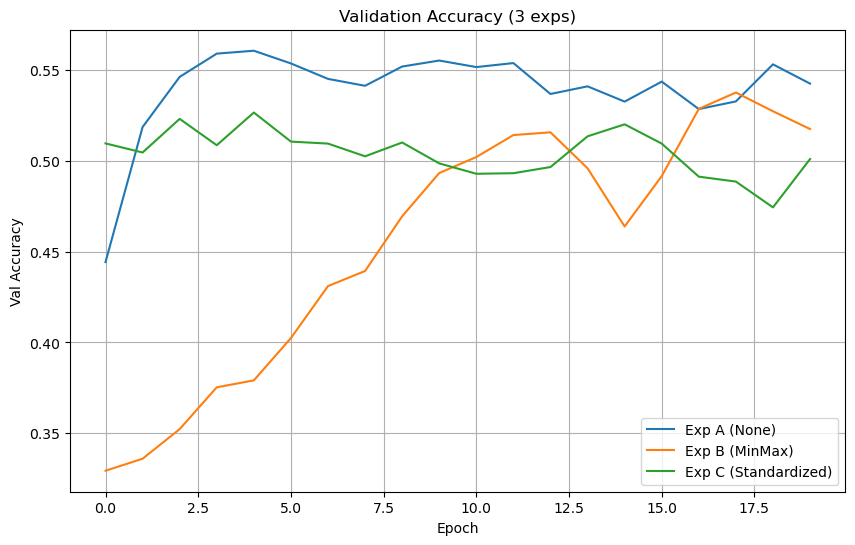

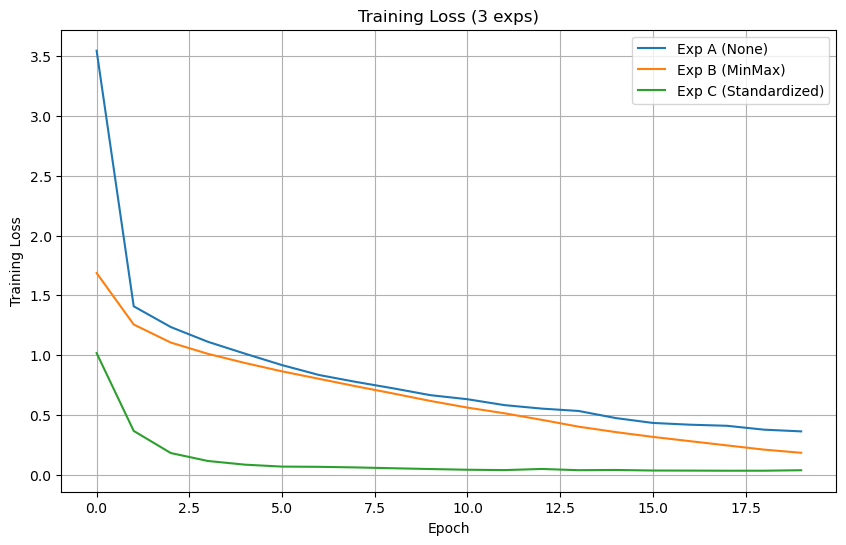

In [24]:
# Now let's gather the histories together to plot them out.
histories = [history_exp_a, history_exp_b, history_exp_c]
labels = ['Exp A (None)','Exp B (MinMax)','Exp C (Standardized)']

# Finally the plotting step 🤩
plot_curves(histories, labels, metric = 'val_accuracy', title = "Validation Accuracy (3 exps)", ylabel = "Val Accuracy")
plot_curves(histories, labels, metric = 'loss', title = "Training Loss (3 exps)", ylabel = "Training Loss")
